<a href="{{ colab_base_laboratorios }}/Laboratorio_01_pinguinos_v2.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **Laboratorio N°1 — Observatorio de Datos (Pingüinos)**

- **Curso:** Aprendizaje Estadistico 2026-2
- **Estudiante:** Jerónimo López Gómez **C.C.** ******5333

**Objetivo**

Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

**Requisitos**

- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

**FASE 1 — Enfoque clásico** (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.


- **Parte A** — Observación inicial

1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

In [ ]:
import pandas as pd 
import seaborn as sns

#Load the dataset
pen_df = sns.load_dataset('penguins')

#1. Columnas y Filas Totales
print(f'Columnas Totales: {len(pen_df.columns)}\nFilas totales: {len(pen_df)}')
print('--'*50)
#2. Variables Numericas vs Categoricas
print(f"""Clasificacion de Variables:\n\nColumnas Numericas: {pen_df.select_dtypes(include='number').columns}
    \nColumnas Categoricas: {pen_df.select_dtypes(include=['category', 'str']).columns}""")
print('--'*50)
#3. Valores Faltantes
print(f'Datos faltantes por columna: {pen_df.isnull().sum()}')
print('--'*50)
#4. Filas Duplicadas
print(f'Filas duplicadas: {pen_df.duplicated().sum()}')
print('--'*50)
#5. Cardinalidad de Variables
print(f'Porcentaje de Cardinalidad:\n{((pen_df.nunique() / len(pen_df)).round(3)).sort_values()}')

pen_df

Columnas Totales: 7
Filas totales: 344
----------------------------------------------------------------------------------------------------
Clasificacion de Variables:

Columnas Numericas: Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='str')
    
Columnas Categoricas: Index(['species', 'island', 'sex'], dtype='str')
----------------------------------------------------------------------------------------------------
Datos faltantes por columna: species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
----------------------------------------------------------------------------------------------------
Filas duplicadas: 0
----------------------------------------------------------------------------------------------------
Porcentaje de Cardinalidad:
sex                  0.006
species              0.009
island               0.009
f

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


- **Parte B** — Descripción

6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

In [ ]:
#6. Estadisticos Variables Numéricas

df_num = pen_df.select_dtypes(include=['number'])

num_stats = pd.DataFrame(
    {
    'Media': df_num.mean().round(2),
    'Mediana': df_num.median().round(2),
    'Desv_Est': df_num.std().round(2),
    'Rango_Intercuatil': (df_num.quantile(0.75) - df_num.quantile(0.25)).round(2)
    }
)

print(f'\nEstadisticos Variables Numericas')

num_stats


Estadisticos Variables Numericas


,Media,Mediana,Desv_Est,Rango_Intercuatil
bill_length_mm,43.92,44.45,5.46,9.27
bill_depth_mm,17.15,17.30,1.97,3.10
flipper_length_mm,200.92,197.00,14.06,23.00
body_mass_g,4201.75,4050.00,801.95,1200.00


In [ ]:
#7. Conteos Variables Categoricas

df_cat = pen_df.select_dtypes(include=['str'])

cat_count = pd.DataFrame(
    {'Conteos': df_cat.value_counts(),
    'Porcentajes': (df_cat.value_counts(normalize=True)).round(3)
    })

print(f'\nConteos Variables Categoricas')

cat_count


Conteos Variables Categoricas


Conteos  Porcentajes
species   island    sex                         
Gentoo    Biscoe    Male         61        0.183
                    Female       58        0.174
Chinstrap Dream     Female       34        0.102
                    Male         34        0.102
Adelie    Dream     Male         28        0.084
                    Female       27        0.081
          Torgersen Female       24        0.072
                    Male         23        0.069
          Biscoe    Female       22        0.066
                    Male         22        0.066

In [172]:
#8. Tablas Cruzadas 

spec_sex = pd.crosstab(
    pen_df['species'],
    pen_df['sex'],
    )
spec_sex.columns.name = None
spec_sex.index.name = None

spec_isl = pd.crosstab(
    pen_df['species'],
    pen_df['island'],
    )
spec_isl.columns.name = None
spec_isl.index.name = None

isl_sex = pd.crosstab(
    pen_df['island'],
    pen_df['sex'],
    )
isl_sex.columns.name = None
isl_sex.index.name = None

print(f'Specie vs Sex Table')
display(spec_sex)
print('--'*50)
print(f'Specie vs Island Table')
display(spec_isl)
print('--'*50)
print(f'Island vs Sex Table')
display(isl_sex)

Specie vs Sex Table


,Female,Male
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


----------------------------------------------------------------------------------------------------
Specie vs Island Table


,Biscoe,Dream,Torgersen
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


----------------------------------------------------------------------------------------------------
Island vs Sex Table


,Female,Male
Biscoe,80,83
Dream,61,62
Torgersen,24,23


In [197]:
#9. Matrices de Correlacion

import matplotlib.pyplot as plt

spear_corr = pen_df.select_dtypes(include='number').corr(method='spearman')
pears_corr = pen_df.select_dtypes(include='number').corr(method='pearson')

print(f'Matriz de Correlación - Método Spearman')
display(spear_corr.round(3))
print('--'*50)
print(f'Matriz de Correlación - Método Pearson')
display(pears_corr.round(3))

Matriz de Correlación - Método Spearman


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.222,0.673,0.584
bill_depth_mm,-0.222,1.000,-0.523,-0.432
flipper_length_mm,0.673,-0.523,1.000,0.840
body_mass_g,0.584,-0.432,0.840,1.000


----------------------------------------------------------------------------------------------------
Matriz de Correlación - Método Pearson


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.235,0.656,0.595
bill_depth_mm,-0.235,1.000,-0.584,-0.472
flipper_length_mm,0.656,-0.584,1.000,0.871
body_mass_g,0.595,-0.472,0.871,1.000


-**Parte C** — Visualización

10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

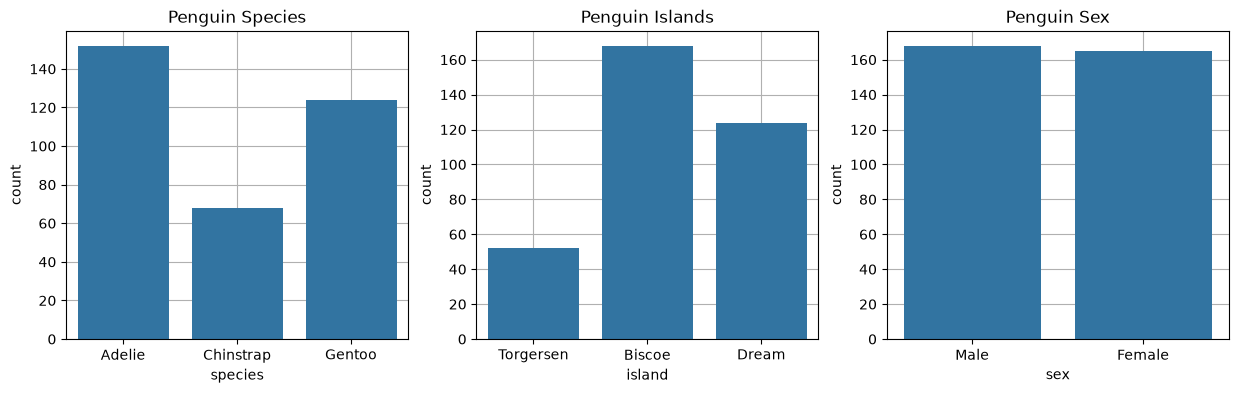

In [216]:
#10. Graficos de Conteo Variables de baja Cardinalidad

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=pen_df, x='species', zorder=2, ax=ax[0])
ax[0].set_title('Penguin Species')
ax[0].grid(zorder=1)

sns.countplot(data=pen_df, x='island', zorder=2, ax=ax[1])
ax[1].set_title('Penguin Islands')
ax[1].grid(zorder=1)

sns.countplot(data=pen_df, x='sex', zorder=2, ax=ax[2])
ax[2].set_title('Penguin Sex')
ax[2].grid(zorder=1)

plt.show()

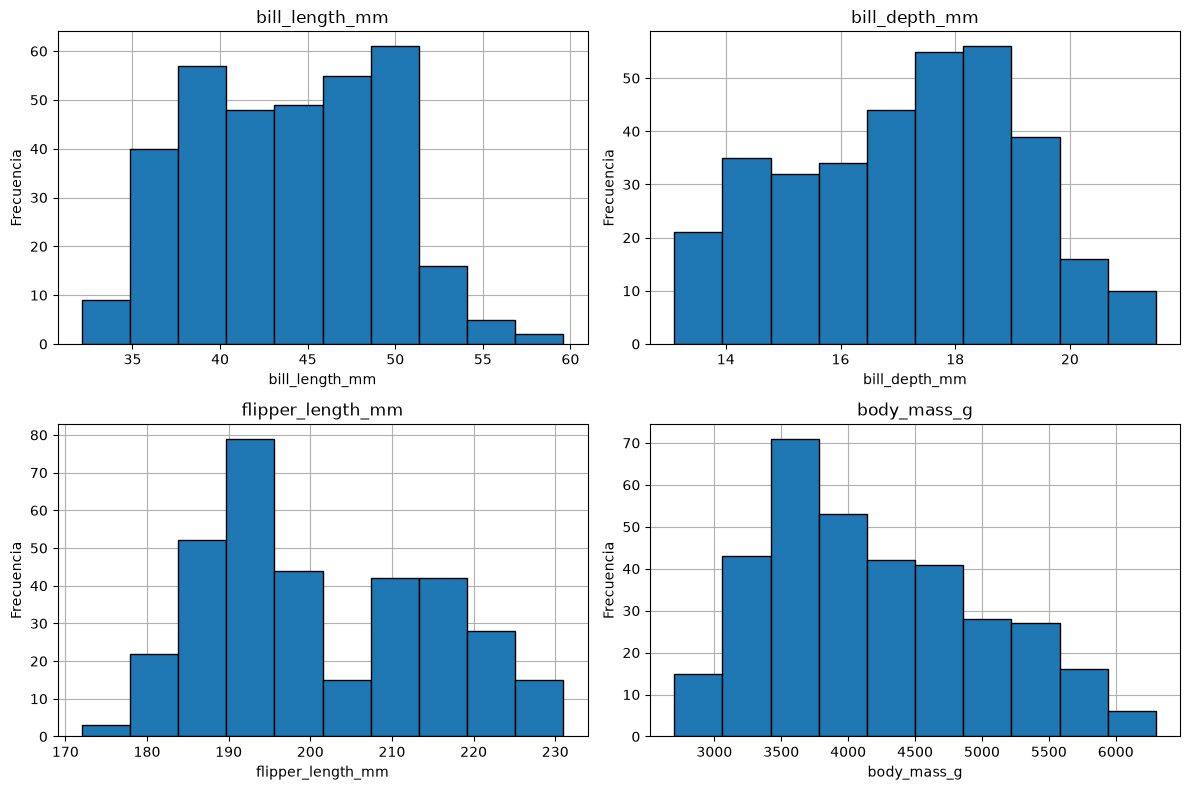

In [239]:
#11. Histogramas para Variables Numericas

num_cols = pen_df.select_dtypes(include='number').columns

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for col, axis in zip(num_cols, ax.flat):
    axis.hist(pen_df[col], bins=10, edgecolor='black', zorder=2)
    axis.set_title(f'{col}')
    axis.set_xlabel(col)
    axis.grid(zorder=1)
    axis.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

- `bill_length_mm` Presenta una distribución de datos relativamente uniforme y concentrada entre los limites de 35 y 50 aproximadamente, sin un pico predominante notable, sin sesgo aparente

- `bill_depth_mm` Presenta pico predominante alrededor de 20 donde encontramos un conjunto de datos con un leve sesgo a la izquierda

- `flipper_length_mm` Este histograma presenta una distribucion de datos alrededor de 2 picos definidos aproximadamente en 190 y 210, donde el primero es mas predominante que el segundo por 2 veces, por tanto estos datos se distribuyen alrededor de 2 zonas distintas

- `body_mass_g` presenta un histograma claramente con un sesgo a la dereca con un pico predominante alrededor de 3500 y con la mayoria de los datos distribuidos a su derecha.

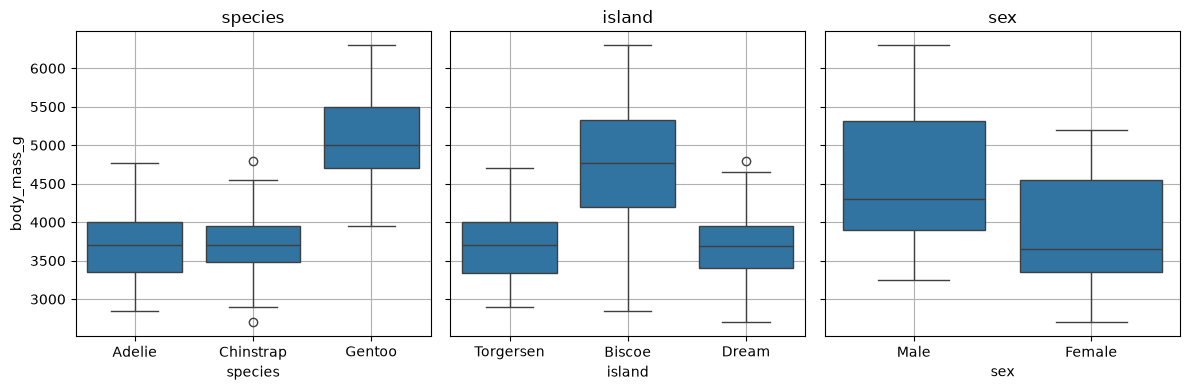

In [ ]:
#12. BoxPlot de una variable numerica por categorias 

cat_cols = pen_df.select_dtypes(include='str').columns

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for col, axis in zip(cat_cols, ax.flat):
    sns.boxplot(data=pen_df, x=col, y='body_mass_g', zorder=2, ax=axis)
    axis.set_title(f'{col}')
    axis.set_xlabel(col)
    axis.grid(zorder=1)
    axis.set_xlabel(f'{col}')

plt.tight_layout()
plt.show()

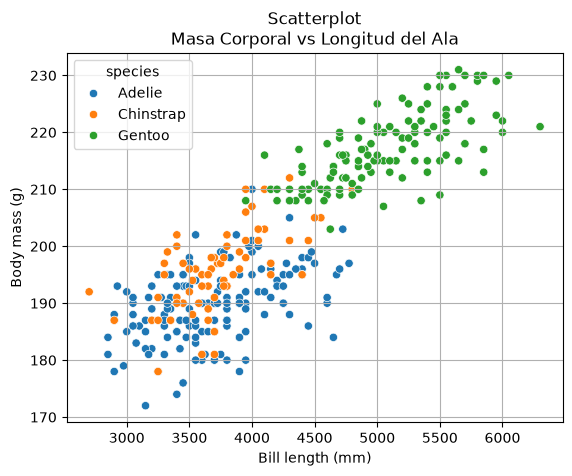

In [ ]:
#13. Scatter de 2 variables numericas coloreada por una categorica

sns.scatterplot(data=pen_df, x='body_mass_g', y='flipper_length_mm', hue='species')

plt.title('Scatterplot\nMasa Corporal vs Longitud del Ala')
plt.xlabel('flipper length (mm)')
plt.ylabel('Body mass (g)')
plt.grid(zorder=1)
plt.show()

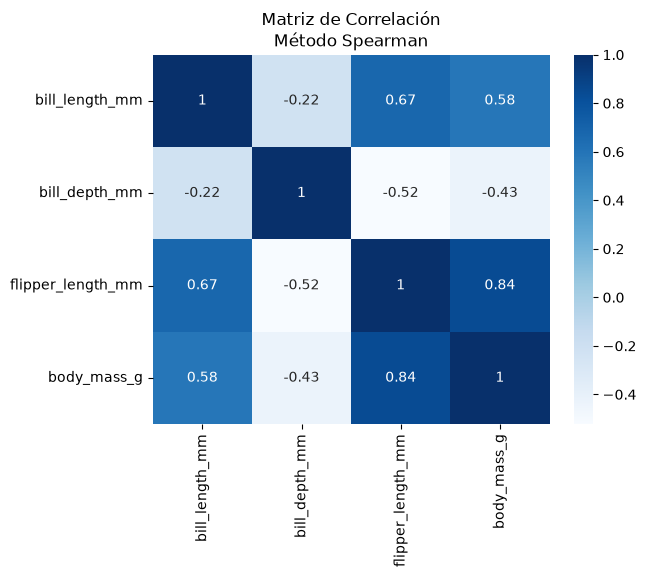

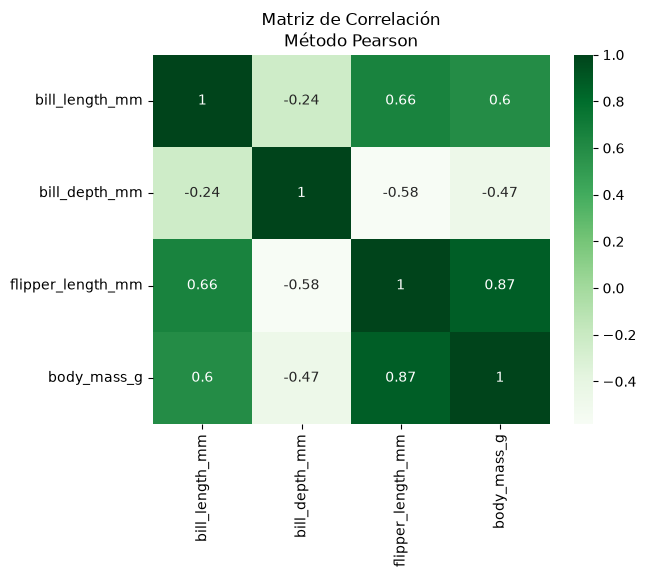

In [259]:
#14. Heatmaps de Correlacion (ver punto 9)

sns.heatmap(spear_corr, annot=True, cmap='Blues')
plt.title('Matriz de Correlación\nMétodo Spearman')
plt.show()

sns.heatmap(pears_corr, annot=True, cmap='Greens')
plt.title('Matriz de Correlación\nMétodo Pearson')
plt.show()

- **Parte D** — Hipótesis (sin causalidad)

15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

15. **Respuesta**

- *Hipótesis 1:* 